Import dependencies/libraries and the dataset

In [104]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, mean_absolute_error, mean_squared_error, r2_score
import numpy as np

file_path = "../dataset/prepared/ClassifierPreparedDataset.csv"
df = pd.read_csv(file_path)

Define the features (X) and the target (y)

In [105]:
X = df.drop(columns=["NLOS"])
y = df["NLOS"]

Split the dataset into 70% training and 30% test

In [106]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=111)

Test the performance of KNN and determine the best value of K to choose. Use Euclidean distance

k = 1 => Training Accuracy: 1.0000, Test Accuracy: 0.7575
k = 5 => Training Accuracy: 0.8534, Test Accuracy: 0.7886
k = 6 => Training Accuracy: 0.8403, Test Accuracy: 0.7946
k = 7 => Training Accuracy: 0.8401, Test Accuracy: 0.7939
k = 8 => Training Accuracy: 0.8313, Test Accuracy: 0.7974
k = 10 => Training Accuracy: 0.8257, Test Accuracy: 0.7985
k = 15 => Training Accuracy: 0.8192, Test Accuracy: 0.7951
k = 20 => Training Accuracy: 0.8122, Test Accuracy: 0.7965
k = 25 => Training Accuracy: 0.8100, Test Accuracy: 0.7975
k = 30 => Training Accuracy: 0.8063, Test Accuracy: 0.7983


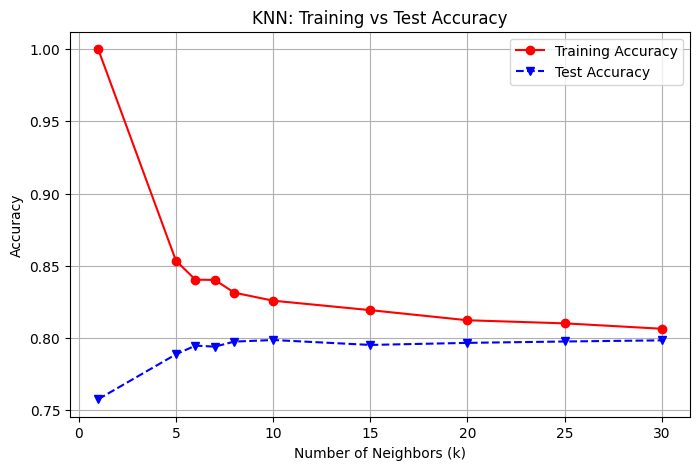

In [107]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

numNeighbors = [1, 5, 6, 7, 8, 10, 15, 20, 25, 30]
trainAcc = []
testAcc = []

for k in numNeighbors:
    clf1 = KNeighborsClassifier(n_neighbors=k, metric='minkowski', p=2)
    clf1.fit(X_train, y_train)
    y_predTrain = clf1.predict(X_train)
    y_predTest = clf1.predict(X_test)
    trainAcc.append(accuracy_score(y_train, y_predTrain))
    testAcc.append(accuracy_score(y_test, y_predTest))
    print(f"k = {k} => Training Accuracy: {accuracy_score(y_train, y_predTrain):.4f}, Test Accuracy: {accuracy_score(y_test, y_predTest):.4f}")

plt.figure(figsize=(8,5))
plt.plot(numNeighbors, trainAcc, 'ro-', label='Training Accuracy')
plt.plot(numNeighbors, testAcc, 'bv--', label='Test Accuracy')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Accuracy')
plt.title('KNN: Training vs Test Accuracy')
plt.legend()
plt.grid(True)
plt.show()


Cross-validation with 5-fold to determine best value for K

k = 1 => CV Accuracy (on training set): 0.7525 (+/- 0.0092)
k = 5 => CV Accuracy (on training set): 0.7845 (+/- 0.0066)
k = 6 => CV Accuracy (on training set): 0.7924 (+/- 0.0094)
k = 7 => CV Accuracy (on training set): 0.7906 (+/- 0.0076)
k = 8 => CV Accuracy (on training set): 0.7945 (+/- 0.0070)
k = 10 => CV Accuracy (on training set): 0.7952 (+/- 0.0082)
k = 15 => CV Accuracy (on training set): 0.7929 (+/- 0.0066)
k = 20 => CV Accuracy (on training set): 0.7943 (+/- 0.0073)
k = 25 => CV Accuracy (on training set): 0.7932 (+/- 0.0071)
k = 30 => CV Accuracy (on training set): 0.7938 (+/- 0.0080)

Best k (based on training set CV): 10 with a 5-Fold CV Accuracy of: 0.7952


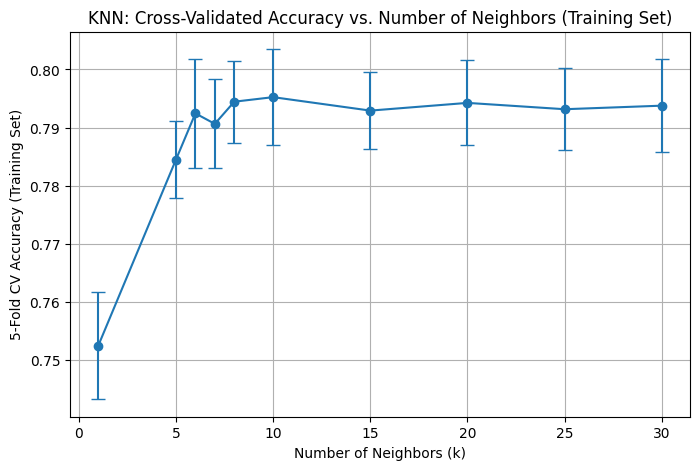

In [108]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt
import numpy as np

# Define the k values to test
num_neighbors = [1, 5, 6, 7, 8, 10, 15, 20, 25, 30]
cv_mean_scores = []
cv_std_scores = []

# Loop through each k value and perform 5-fold cross-validation on the training set
for k in num_neighbors:
    knn = KNeighborsClassifier(n_neighbors=k, metric='minkowski', p=2)
    scores = cross_val_score(knn, X_train, y_train, cv=5, scoring='accuracy')
    cv_mean_scores.append(scores.mean())
    cv_std_scores.append(scores.std())
    print(f"k = {k} => CV Accuracy (on training set): {scores.mean():.4f} (+/- {scores.std():.4f})")

# Identify the best k value based on cross-validation on the training set
best_index = np.argmax(cv_mean_scores)
best_k = num_neighbors[best_index]
best_accuracy = cv_mean_scores[best_index]
print(f"\nBest k (based on training set CV): {best_k} with a 5-Fold CV Accuracy of: {best_accuracy:.4f}")

# Plot the cross-validation results with error bars showing the standard deviation
plt.figure(figsize=(8,5))
plt.errorbar(num_neighbors, cv_mean_scores, yerr=cv_std_scores, fmt='o-', capsize=5)
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('5-Fold CV Accuracy (Training Set)')
plt.title('KNN: Cross-Validated Accuracy vs. Number of Neighbors (Training Set)')
plt.grid(True)
plt.show()


Mean and Standard Deviation, Paired t-Test for K value to choose between 10 or 20

Confusion Matrix for K=10 KNN Model training

Final Test Accuracy: 0.7984920634920635

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.90      0.82      6278
           1       0.87      0.70      0.78      6322

    accuracy                           0.80     12600
   macro avg       0.81      0.80      0.80     12600
weighted avg       0.81      0.80      0.80     12600

Confusion Matrix:
[[5628  650]
 [1889 4433]]


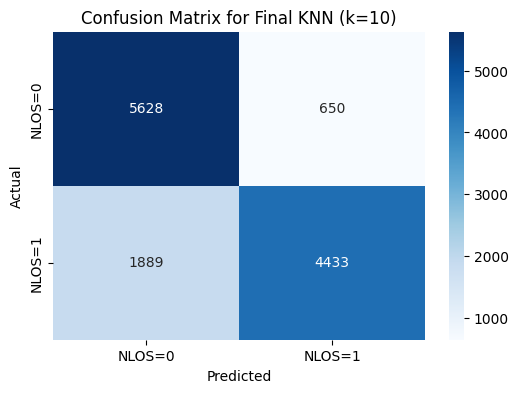

In [109]:
# Final Model Training and Evaluation using k=10

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Create and train the final KNN model on the training set
final_knn = KNeighborsClassifier(n_neighbors=10, metric='minkowski', p=2)
final_knn.fit(X_train, y_train)

# 2. Predict on the test set
y_pred = final_knn.predict(X_test)

# 3. Evaluate Performance
final_accuracy = accuracy_score(y_test, y_pred)
print("Final Test Accuracy:", final_accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

# 4. Visualize the confusion matrix with custom labels
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["NLOS=0", "NLOS=1"],
            yticklabels=["NLOS=0", "NLOS=1"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix for Final KNN (k=10)")
plt.show()

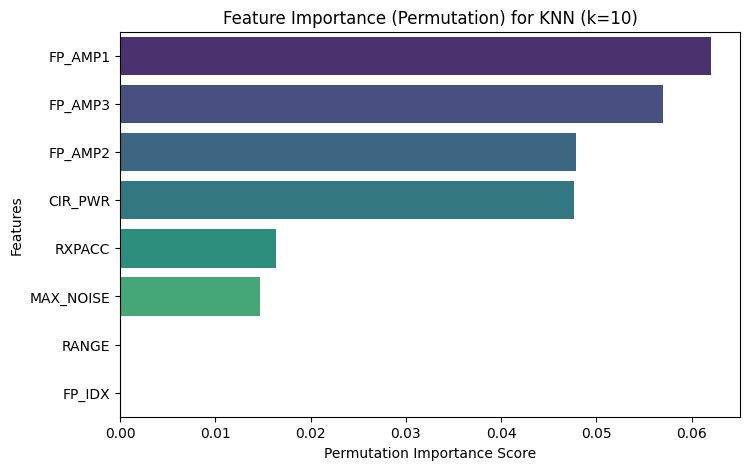

In [110]:
# ==============================
# Permutation Importance for KNN
# ==============================

from sklearn.inspection import permutation_importance

# 5. Estimate feature importance via permutation
# We pass the final KNN model, plus the same X_test, y_test used for evaluation
r = permutation_importance(final_knn, X_test, y_test, n_repeats=10, random_state=111)

# r.importances_mean gives the average drop in accuracy (or scoring metric)
# when each feature is shuffled
perm_importances = pd.Series(r.importances_mean, index=X.columns).sort_values(ascending=False)

# 6. Plot the permutation importances
plt.figure(figsize=(8,5))

# Plotting with explicit 'hue' to satisfy the new requirement
ax = sns.barplot(
    x=perm_importances.values,
    y=perm_importances.index,
    hue=perm_importances.index,
    palette="viridis",
    dodge=False
)

# Remove the legend to match the old behavior (one bar per feature)
if ax.legend_:
    ax.legend_.remove()

plt.xlabel("Permutation Importance Score")
plt.ylabel("Features")
plt.title("Feature Importance (Permutation) for KNN (k=10)")
plt.show()



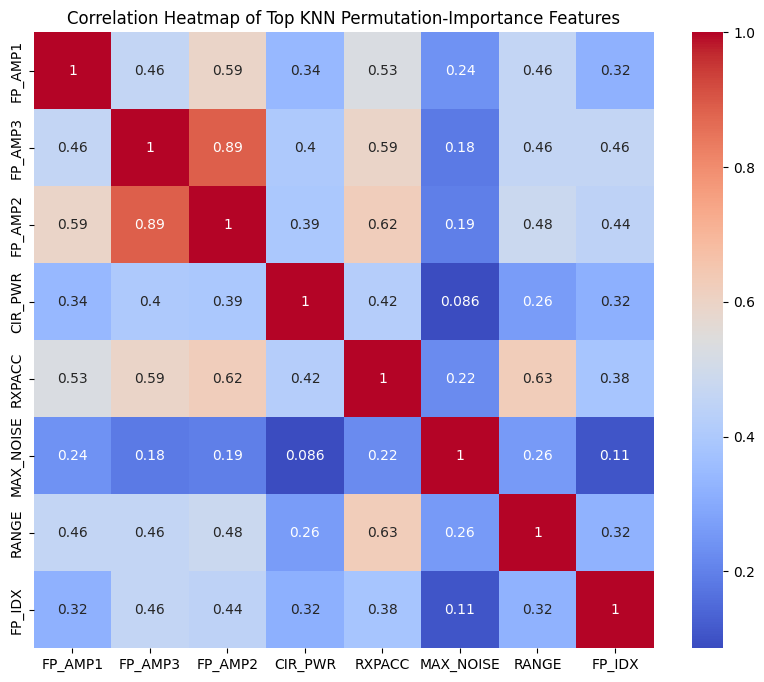

In [111]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define the features from your permutation importance chart
features = [
    "FP_AMP1", 
    "FP_AMP3", 
    "FP_AMP2", 
    "CIR_PWR", 
    "RXPACC", 
    "MAX_NOISE", 
    "RANGE", 
    "FP_IDX"
]

# 1. Create a correlation matrix (absolute values to highlight strong relationships)
corr_matrix = df[features].corr().abs()

# 2. Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap of Top KNN Permutation-Importance Features")
plt.show()


Since FP_AMP2 and FP_AMP3 are both highly correlated we can drop either one. However, as seen in the feature importance barplot, FP_AMP3 has higher feature importance than FP_AMP2. Hence we drop FP_AMP2 in this case.

Reload the dataset again.

In [112]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, mean_absolute_error, mean_squared_error, r2_score
import numpy as np

file_path = "../dataset/prepared/ClassifierPreparedDataset.csv"
df = pd.read_csv(file_path)

drop range,FP_IDX, FP_AMP2 for final feature selection.

In [113]:
# Suppose your DataFrame is named df
df = df.drop(columns=['RANGE', 'FP_IDX','FP_AMP2'])
print("Columns in df after dropping:", df.columns.tolist())
print("\nPreview of DataFrame after dropping columns:")
print(df.head())



Columns in df after dropping: ['NLOS', 'FP_AMP1', 'FP_AMP3', 'CIR_PWR', 'MAX_NOISE', 'RXPACC']

Preview of DataFrame after dropping columns:
   NLOS  FP_AMP1  FP_AMP3  CIR_PWR  MAX_NOISE  RXPACC
0     0    18712    11576    11855        967     611
1     0    11239     4712    18968       1133     447
2     1     4355     3478    14699        894     723
3     1     8502     5890     8748       1127    1024
4     0    17845    12058    11380       1744     276


Define the feature (X) and Targert (Y)

In [114]:
X = df.drop(columns=["NLOS"])
y = df["NLOS"]

Train the dataset 80% train, 20% test

In [115]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=111)

k = 1 => Training Accuracy: 1.0000, Test Accuracy: 0.7732
k = 5 => Training Accuracy: 0.8607, Test Accuracy: 0.8074
k = 6 => Training Accuracy: 0.8464, Test Accuracy: 0.8081
k = 7 => Training Accuracy: 0.8498, Test Accuracy: 0.8052
k = 8 => Training Accuracy: 0.8399, Test Accuracy: 0.8079
k = 10 => Training Accuracy: 0.8339, Test Accuracy: 0.8090
k = 15 => Training Accuracy: 0.8284, Test Accuracy: 0.8075
k = 20 => Training Accuracy: 0.8199, Test Accuracy: 0.8087
k = 25 => Training Accuracy: 0.8174, Test Accuracy: 0.8058
k = 30 => Training Accuracy: 0.8126, Test Accuracy: 0.8068


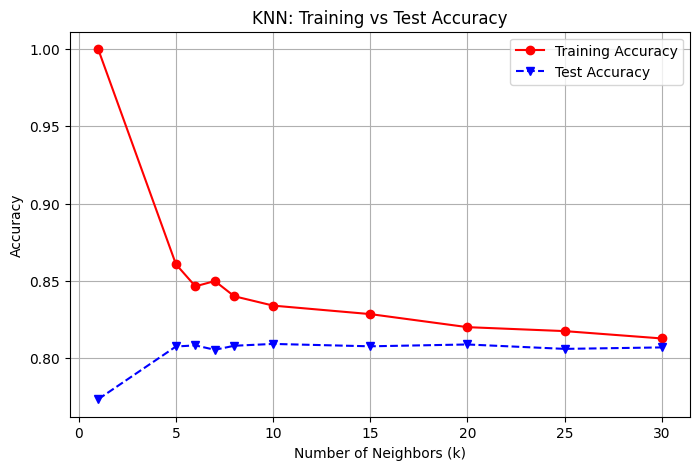

In [116]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

numNeighbors = [1, 5, 6, 7, 8, 10, 15, 20, 25, 30]
trainAcc = []
testAcc = []

for k in numNeighbors:
    clf1 = KNeighborsClassifier(n_neighbors=k, metric='minkowski', p=2)
    clf1.fit(X_train, y_train)
    y_predTrain = clf1.predict(X_train)
    y_predTest = clf1.predict(X_test)
    trainAcc.append(accuracy_score(y_train, y_predTrain))
    testAcc.append(accuracy_score(y_test, y_predTest))
    print(f"k = {k} => Training Accuracy: {accuracy_score(y_train, y_predTrain):.4f}, Test Accuracy: {accuracy_score(y_test, y_predTest):.4f}")

plt.figure(figsize=(8,5))
plt.plot(numNeighbors, trainAcc, 'ro-', label='Training Accuracy')
plt.plot(numNeighbors, testAcc, 'bv--', label='Test Accuracy')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Accuracy')
plt.title('KNN: Training vs Test Accuracy')
plt.legend()
plt.grid(True)
plt.show()


k = 1 => CV Accuracy (on training set): 0.7667 (+/- 0.0043)
k = 5 => CV Accuracy (on training set): 0.7995 (+/- 0.0048)
k = 6 => CV Accuracy (on training set): 0.8026 (+/- 0.0055)
k = 7 => CV Accuracy (on training set): 0.8022 (+/- 0.0046)
k = 8 => CV Accuracy (on training set): 0.8026 (+/- 0.0054)
k = 10 => CV Accuracy (on training set): 0.8034 (+/- 0.0048)
k = 15 => CV Accuracy (on training set): 0.8024 (+/- 0.0058)
k = 20 => CV Accuracy (on training set): 0.8021 (+/- 0.0076)
k = 25 => CV Accuracy (on training set): 0.8006 (+/- 0.0067)
k = 30 => CV Accuracy (on training set): 0.7987 (+/- 0.0069)

Best k (based on training set CV): 10 with a 5-Fold CV Accuracy of: 0.8034


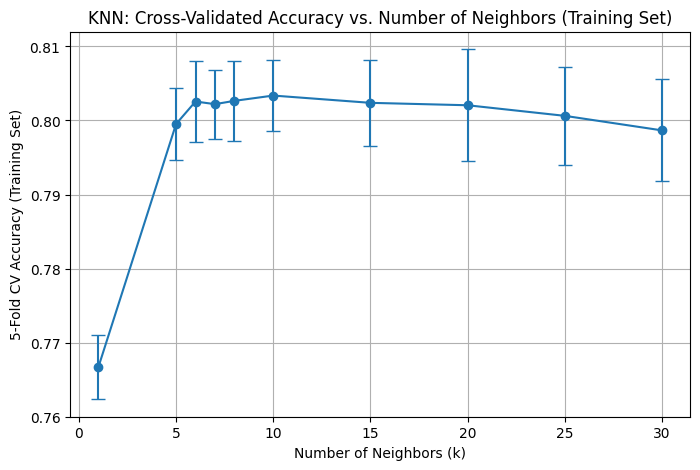

In [117]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt
import numpy as np

# Define the k values to test
num_neighbors = [1, 5, 6, 7, 8, 10, 15, 20, 25, 30]
cv_mean_scores = []
cv_std_scores = []

# Loop through each k value and perform 5-fold cross-validation on the training set
for k in num_neighbors:
    knn = KNeighborsClassifier(n_neighbors=k, metric='minkowski', p=2)
    scores = cross_val_score(knn, X_train, y_train, cv=5, scoring='accuracy')
    cv_mean_scores.append(scores.mean())
    cv_std_scores.append(scores.std())
    print(f"k = {k} => CV Accuracy (on training set): {scores.mean():.4f} (+/- {scores.std():.4f})")

# Identify the best k value based on cross-validation on the training set
best_index = np.argmax(cv_mean_scores)
best_k = num_neighbors[best_index]
best_accuracy = cv_mean_scores[best_index]
print(f"\nBest k (based on training set CV): {best_k} with a 5-Fold CV Accuracy of: {best_accuracy:.4f}")

# Plot the cross-validation results with error bars showing the standard deviation
plt.figure(figsize=(8,5))
plt.errorbar(num_neighbors, cv_mean_scores, yerr=cv_std_scores, fmt='o-', capsize=5)
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('5-Fold CV Accuracy (Training Set)')
plt.title('KNN: Cross-Validated Accuracy vs. Number of Neighbors (Training Set)')
plt.grid(True)
plt.show()


Final Test Accuracy: 0.809047619047619

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.90      0.83      4225
           1       0.88      0.71      0.79      4175

    accuracy                           0.81      8400
   macro avg       0.82      0.81      0.81      8400
weighted avg       0.82      0.81      0.81      8400

Confusion Matrix:
[[3819  406]
 [1198 2977]]


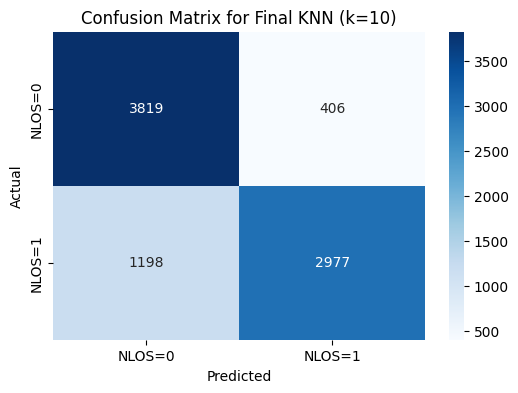

In [118]:
# Final Model Training and Evaluation using k=10

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Create and train the final KNN model on the training set
final_knn = KNeighborsClassifier(n_neighbors=10, metric='minkowski', p=2)
final_knn.fit(X_train, y_train)

# 2. Predict on the test set
y_pred = final_knn.predict(X_test)

# 3. Evaluate Performance
final_accuracy = accuracy_score(y_test, y_pred)
print("Final Test Accuracy:", final_accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

# 4. Visualize the confusion matrix with custom labels
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["NLOS=0", "NLOS=1"],
            yticklabels=["NLOS=0", "NLOS=1"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix for Final KNN (k=10)")
plt.show()


Permutation Importance for KNN

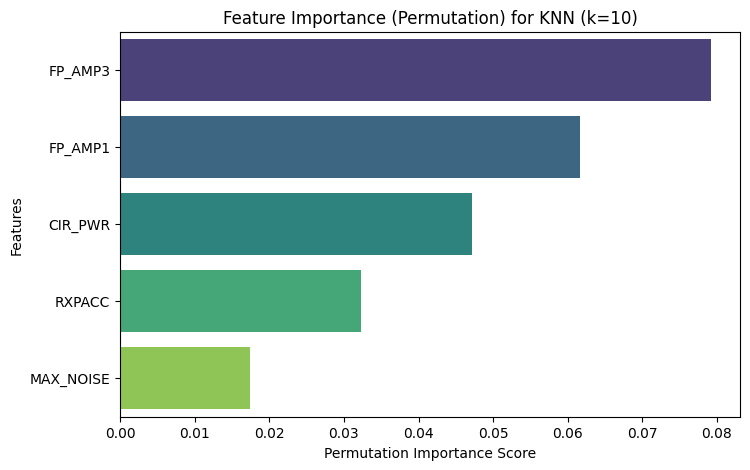

In [119]:
# ==============================
# Permutation Importance for KNN
# ==============================

from sklearn.inspection import permutation_importance

# 5. Estimate feature importance via permutation
# We pass the final KNN model, plus the same X_test, y_test used for evaluation
r = permutation_importance(final_knn, X_test, y_test, n_repeats=10, random_state=111)

# r.importances_mean gives the average drop in accuracy (or scoring metric)
# when each feature is shuffled
perm_importances = pd.Series(r.importances_mean, index=X.columns).sort_values(ascending=False)

# 6. Plot the permutation importances
plt.figure(figsize=(8,5))

# Plotting with explicit 'hue' to satisfy the new requirement
ax = sns.barplot(
    x=perm_importances.values,
    y=perm_importances.index,
    hue=perm_importances.index,
    palette="viridis",
    dodge=False
)

# Remove the legend to match the old behavior (one bar per feature)
if ax.legend_:
    ax.legend_.remove()

plt.xlabel("Permutation Importance Score")
plt.ylabel("Features")
plt.title("Feature Importance (Permutation) for KNN (k=10)")
plt.show()

